#### **Importing required libaries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
import seaborn as sns
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout,LeakyReLU,PReLU,ELU,BatchNormalization,ReLU

#### **Loading dataset**

In [2]:
df=pd.read_csv('Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### **Data preprocessing**

In [4]:
df=df.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [5]:
X=df.drop('Exited',axis=1)
y=df['Exited']

In [6]:
X['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
geography_dummies=pd.get_dummies(X['Geography'],drop_first=True).astype('int64')

In [8]:
gender_dummies=pd.get_dummies(X['Gender'],drop_first=True).astype('int64')

In [9]:
X.drop(['Geography','Gender'],axis=1,inplace=True)

In [10]:
X=pd.concat([X,geography_dummies,gender_dummies],axis=1)

In [11]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


#### **Splitting dataset into training and test dataset**

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test : {y_test.shape}")

X_train : (8000, 11)
X_test : (2000, 11)
y_train : (8000,)
y_test : (2000,)


#### **Feature Scaling**

In [14]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [15]:
X_train

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(8000, 11))

In [16]:
X_test

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(2000, 11))

#### **Creation of Neural Network**

In [17]:
# Initializing the ANN
classifier=Sequential()

In [18]:
# adding input layer
classifier.add(Dense(units=11,activation='relu'))


In [19]:
# 1st hidden layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.3))

In [20]:
# 2nd hidden layer
classifier.add(Dense(units=6,activation='relu'))


In [21]:
# output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [22]:
# setting value of learning rate
opt=tf.keras.optimizers.Adam(learning_rate=0.01)

#### **Model Configuration**

In [23]:
# to configure the model Which optimizer to use → how weights will update
# Which loss function to use → how error is calculated
# Which metrics to track → like accuracy

classifier.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

In [24]:
# early stopping
early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='auto',verbose=0,patience=0,restore_best_weights=False,baseline=None,min_delta=0)

#### **Model Training**

In [25]:
# model training
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=100,callbacks=early_stopping)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7988 - loss: 0.4562 - val_accuracy: 0.8190 - val_loss: 0.4136
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8268 - loss: 0.4011 - val_accuracy: 0.8482 - val_loss: 0.3808
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8382 - loss: 0.3785 - val_accuracy: 0.8444 - val_loss: 0.3789
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8451 - loss: 0.3736 - val_accuracy: 0.8432 - val_loss: 0.3772
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8455 - loss: 0.3755 - val_accuracy: 0.8429 - val_loss: 0.4048


In [26]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

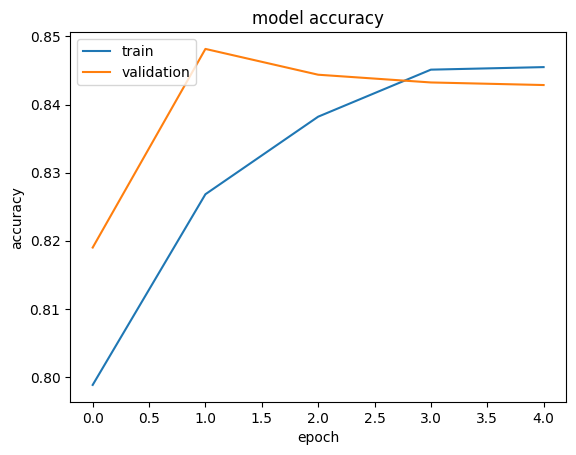

In [27]:
### plot the history
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','validation'],loc='upper left')
plt.show()

In [28]:
classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815 (3.19 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 544 (2.13 KB)

In [29]:
# making prediction
y_pred=classifier.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [30]:
print(y_pred)

[[0.18034829]
 [0.09588687]
 [0.209442  ]
 ...
 [0.7328972 ]
 [0.37614214]
 [0.37614214]]


#### **Model Prediction**

In [31]:
y_pred=(y_pred>=0.5).astype('int64')

In [32]:
print(y_pred)

[[0]
 [0]
 [0]
 ...
 [1]
 [0]
 [0]]


#### **Confusion Matrix**

In [39]:

from sklearn.metrics import confusion_matrix,classification_report  
cm=confusion_matrix(y_test,y_pred)
cm

array([[1520,   87],
       [ 211,  182]])

In [34]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)

In [35]:
print(f"Accuracy  : {score*100} %")

Accuracy  : 85.1 %


In [36]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.88      0.95      0.91      1607\n           1       0.68      0.46      0.55       393\n\n    accuracy                           0.85      2000\n   macro avg       0.78      0.70      0.73      2000\nweighted avg       0.84      0.85      0.84      2000\n'

<Axes: >

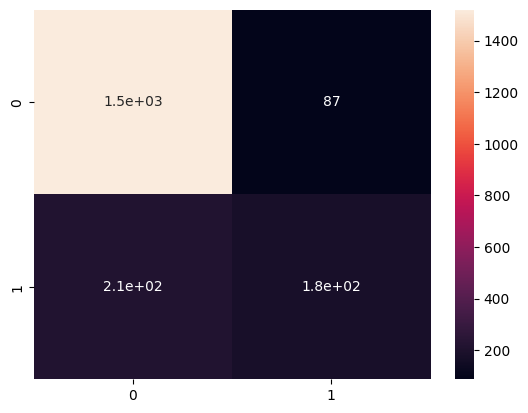

In [37]:

sns.heatmap(cm,annot=True)


#### **Save the Model**

In [38]:
# save the model in pickle
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(classifier, file)
